   # Proyecto Final

# Análisis Exploratorio de Datos (EDA)

## Dataset de Ventas - Superstore

### Integrantes

- Integrante 1: Emerson Suquillo
- Integrante 2: Angelica Paredes
- Integrante 3: Luis Chuqui

**Asignatura:** INTRODUCCION A LA PROGRAMACION CON PYTHON

**PROYECTO FINAL:** Análisis Exploratorio de Datos (EDA)


**Docente:** JOEL ENRIQUE CAZA ORRALA

# Introducción

En este proyecto se realizó un Análisis Exploratorio de Datos (EDA) utilizando Python y las bibliotecas Pandas y Matplotlib. El objetivo fue explorar, limpiar y analizar un conjunto de datos de ventas para identificar patrones, tendencias y obtener información que facilite la toma de decisiones.

# Objetivos

## Objetivo General

Realizar un análisis exploratorio de datos del dataset de ventas utilizando Python para identificar información relevante mediante tablas, métricas y visualizaciones.

## Objetivos Específicos

- Explorar la estructura del conjunto de datos.
- Limpiar y transformar la información.
- Analizar las ventas y ganancias por categoría y región.
- Elaborar gráficos que faciliten la interpretación de los resultados.

# Fase 1: Carga y Exploración (Emerson S.)

En esta etapa se importan las bibliotecas necesarias y se carga el conjunto de datos. Posteriormente, se revisa la estructura del DataFrame, los tipos de datos, los valores nulos y los registros duplicados para conocer el estado inicial de la información.

In [1]:
#import pandas as pd.Permite leer y manipular tablas de datos (DataFrames).
#import numpy as np. Sirve para realizar operaciones matemáticas y trabajar con arreglos
#import matplotlib.pyplot as plt. Para la cración de graficos
#from matplotlib.ticker import FuncFormatter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Mostrar números con separador de miles y dos decimales
pd.options.display.float_format = '{:,.2f}'.format

# Función para mostrar dinero en los gráficos
formato_dinero = FuncFormatter(lambda x, pos: f'${x:,.2f}')


In [2]:
"""Busca el archivo Superstore.csv.
Convierte automáticamente el contenido en un DataFrame.
Guarda ese DataFrame en la variable df.
Es decir, el archivo CSV pasa de ser un archivo de texto a un objeto que puedes analizar con Pandas."""

df = pd.read_csv("Superstore.csv", encoding="latin-1")
#df = pd.read_csv("Superstore.csv", encoding="utf-8-sig")# corrije caracteres especiales
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ï»¿ID del Pedido  9994 non-null   object 
 1   fecha_envio       9994 non-null   object 
 2   Region            9994 non-null   object 
 3   categoria         9994 non-null   object 
 4   nombre_producto   9994 non-null   object 
 5   venta             9994 non-null   float64
 6   cantidad          9994 non-null   int64  
 7   descuento         9994 non-null   float64
 8   ganancia          9994 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 702.8+ KB


In [3]:
# Corregir el nombre de la primera columna
df.rename(columns={"ï»¿ID del Pedido": "ID del Pedido"}, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID del Pedido    9994 non-null   object 
 1   fecha_envio      9994 non-null   object 
 2   Region           9994 non-null   object 
 3   categoria        9994 non-null   object 
 4   nombre_producto  9994 non-null   object 
 5   venta            9994 non-null   float64
 6   cantidad         9994 non-null   int64  
 7   descuento        9994 non-null   float64
 8   ganancia         9994 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 702.8+ KB


In [4]:
#Muestra las primeras cinco filas del DataFrame.
#Esto confirma que el archivo fue leído correctamente.
df.head()

,ID del Pedido,fecha_envio,Region,categoria,nombre_producto,venta,cantidad,descuento,ganancia
0,CA-2016-152156,11/11/2016,Sur,Muebles,Bush Somerset Collection Librero,261.96,2,0.00,41.91
1,CA-2016-152156,11/11/2016,Sur,Muebles,"Hon Deluxe Fabric Upholstered Stacking Sillas,...",731.94,3,0.00,219.58
2,CA-2016-138688,6/16/2016,Oeste,Suministros de oficina,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,US-2015-108966,10/18/2015,Sur,Muebles,Bretford CR4500 Series Slim Rectangular Mesa,957.58,5,0.45,-383.03
4,US-2015-108966,10/18/2015,Sur,Suministros de oficina,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [5]:
#Esto confirma que el archivo CSV fue transformado exitosamente en un DataFrame.
type(df)

pandas.core.frame.DataFrame

In [6]:
#Devuelve una tupla con:(filas, columnas)

df.shape

(9994, 9)

In [7]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Número de filas: 9994
Número de columnas: 9


In [8]:
#Conocer el nombre de las columnas
df.columns

Index(['ID del Pedido', 'fecha_envio', 'Region', 'categoria',
       'nombre_producto', 'venta', 'cantidad', 'descuento', 'ganancia'],
      dtype='object')

In [9]:
"""Ver el tipo de datos de cada columna
Tipo	Significado
object	Texto
int64	Número entero
float64	Número decimal
datetime64	Fecha (más adelante convertiremos las fechas a este tipo)"""
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID del Pedido    9994 non-null   object 
 1   fecha_envio      9994 non-null   object 
 2   Region           9994 non-null   object 
 3   categoria        9994 non-null   object 
 4   nombre_producto  9994 non-null   object 
 5   venta            9994 non-null   float64
 6   cantidad         9994 non-null   int64  
 7   descuento        9994 non-null   float64
 8   ganancia         9994 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 702.8+ KB


In [10]:
"""Este comando calcula estadísticas de las columnas numéricas.
Cantidad de datos (count).
Promedio (mean).
Desviación estándar (std).
Valor mínimo (min).
Valor máximo (max).
Percentiles (25 %, 50 % y 75 %)."""
df.describe()

,venta,cantidad,descuento,ganancia
count,"9,994.00","9,994.00","9,994.00","9,994.00"
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,"-6,599.98"
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,"22,638.48",14.00,0.80,"8,399.98"


In [11]:
"""Revisar si existen valores nulos
Este comando verifica cuántos valores faltantes tiene cada columna.
Si todas muestran 0, significa que el dataset está completo y no requiere tratamiento de datos faltantes."""

df.isnull().sum()

ID del Pedido      0
fecha_envio        0
Region             0
categoria          0
nombre_producto    0
venta              0
cantidad           0
descuento          0
ganancia           0
dtype: int64

In [12]:
"""Verificar registros duplicados
Si el resultado es:0
No existen registros duplicados.
Si aparece otro número, esos registros deberán eliminarse durante la limpieza."""


df.duplicated().sum()


np.int64(1)

In [13]:
df = df.drop_duplicates() #para eliminar en caso de que haya duplicados

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["categoria"].unique() # muestra las categorías que existen en el DataFrame

array(['Muebles', 'Suministros de oficina', 'TecnologÃ\xada'],
      dtype=object)

In [16]:
#Sirve para mostrar el tipo de dato de cada columna del DataFrame.
#Es muy útil para comprobar si los datos fueron importados correctamente.

df.dtypes

ID del Pedido       object
fecha_envio         object
Region              object
categoria           object
nombre_producto     object
venta              float64
cantidad             int64
descuento          float64
ganancia           float64
dtype: object

In [17]:
#Antes la fecha era simplemente un texto:11/08/2016 Después de convertirla, Pandas la interpreta como una fecha real.
df["fecha_envio"] = pd.to_datetime(df["fecha_envio"])

In [18]:
# Verificamos que la fecha ya no esta en SRT, ahora es una fecha real 
df.dtypes 

ID del Pedido              object
fecha_envio        datetime64[ns]
Region                     object
categoria                  object
nombre_producto            object
venta                     float64
cantidad                    int64
descuento                 float64
ganancia                  float64
dtype: object

In [19]:
"""¿Por qué hacemos esto?
¿Qué año tuvo mayores ventas?
¿Qué mes fue el mejor?
¿Cuál fue el comportamiento mensual de las ganancias?"""

df["Año"] = df["fecha_envio"].dt.year

df["Mes"] = df["fecha_envio"].dt.month

df["Nombre Mes"] = df["fecha_envio"].dt.month_name()

df["Día"] = df["fecha_envio"].dt.day

In [20]:


df.head() 

,ID del Pedido,fecha_envio,Region,categoria,nombre_producto,venta,cantidad,descuento,ganancia,Año,Mes,Nombre Mes,Día
0,CA-2016-152156,2016-11-11,Sur,Muebles,Bush Somerset Collection Librero,261.96,2,0.00,41.91,2016,11,November,11
1,CA-2016-152156,2016-11-11,Sur,Muebles,"Hon Deluxe Fabric Upholstered Stacking Sillas,...",731.94,3,0.00,219.58,2016,11,November,11
2,CA-2016-138688,2016-06-16,Oeste,Suministros de oficina,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,2016,6,June,16
3,US-2015-108966,2015-10-18,Sur,Muebles,Bretford CR4500 Series Slim Rectangular Mesa,957.58,5,0.45,-383.03,2015,10,October,18
4,US-2015-108966,2015-10-18,Sur,Suministros de oficina,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,2015,10,October,18


#  Fase 2:Limpieza de Datos

En esta fase se preparó el conjunto de datos para el análisis. Se convirtió la columna de fechas al formato adecuado, se crearon nuevas variables de tiempo y se eliminaron los registros duplicados para garantizar la calidad de la información.

# Fase 3: Análisis Descriptivo (Angelica P.)

Se realizaron consultas utilizando las funciones `groupby()` y `pivot_table()` de Pandas para responder preguntas relacionadas con las ventas, las ganancias y el comportamiento de las diferentes categorías y regiones.

In [21]:
#Análisis 1: Ventas por Categoría
#Pregunta 1
#¿Qué categoría tiene mayores ventas?
#Este análisis nos permite identificar cuál de las categorías genera el mayor volumen en ventas dentro del conjunto de datos.

ventas_categoria = (
    df.groupby("categoria")["venta"]
      .sum()
      .sort_values(ascending=False)
)
ventas_categoria.to_frame().style \
    .format("${:,.2f}") \
    .set_caption("Tabla 1. Ventas Totales por Categoría")

,venta
categoria,
TecnologÃ­a,"$836,154.03"
Muebles,"$741,718.42"
Suministros de oficina,"$719,047.03"


In [22]:
#Análisis 2: Ventas por Región
#Pregunta 2
#¿Qué región genera mayores ventas?
#Se analiza el comportamiento de las ventas en cada región para identificar las zonas con mayor actividad comercial.

ventas_region = (
    df.groupby("Region")["venta"]
      .sum()
      .sort_values(ascending=False)
)
ventas_region.to_frame().style \
    .format("${:,.2f}") \
    .set_caption("Tabla 2. Ventas Totales por Región")


,venta
Region,
Oeste,"$725,457.82"
Este,"$678,499.87"
Centro,"$501,239.89"
Sur,"$391,721.91"


In [23]:
#Análisis 3: Ganancias por Categoría
#Pregunta 3
#¿Qué categoría genera mayores ganancias?
#Este análisis nos permite comparar la rentabilidad obtenida por cada categoría de productos.

ganancia_categoria = (
    df.groupby("categoria")["ganancia"]
      .sum()
      .sort_values(ascending=False)
)
ganancia_categoria.to_frame().style \
    .format("${:,.2f}") \
    .set_caption("Tabla 3. Ganancias por Categoría")

,ganancia
categoria,
TecnologÃ­a,"$145,454.95"
Suministros de oficina,"$122,490.80"
Muebles,"$18,463.33"


In [24]:
## Análisis 4: Ganancias por Región
#Pregunta 4
#¿Qué región genera mayores ganancias?
#Se evalúa la distribución de las ganancias en las diferentes regiones para determinar cuáles presentan un mejor desempeño económico.

ganancia_region = (
    df.groupby("Region")["ganancia"]
      .sum()
      .sort_values(ascending=False)
)
 
ganancia_region.to_frame().style \
    .format("${:,.2f}") \
    .set_caption("Tabla 4. Ganancias por Región")

,ganancia
Region,
Oeste,"$108,418.45"
Este,"$91,534.84"
Sur,"$46,749.43"
Centro,"$39,706.36"


In [25]:
# Análisis 5: Tabla Dinámica
#Pregunta 5
#Tabla dinámica Región × Categoría
#Se utiliza una tabla dinámica para relacionar las regiones y las categorías, facilitando la comparación de las ventas entre ambas variables.

tabla = pd.pivot_table(
    df,
    values="venta",
    index="Region",
    columns="categoria",
    aggfunc="sum"
)
tabla.style \
    .format("${:,.2f}") \
    .set_caption("Tabla 5. Ventas por Región y Categoría")

categoria,Muebles,Suministros de oficina,TecnologÃ­a
Region,,,
Centro,"$163,797.16","$167,026.42","$170,416.31"
Este,"$208,009.83","$205,516.05","$264,973.98"
Oeste,"$252,612.74","$220,853.25","$251,991.83"
Sur,"$117,298.68","$125,651.31","$148,771.91"


In [26]:
#Análisis 6: Top 10 de los mejores productos con mayores ventas
#Se relaciono los productos en general para obtener el top10 de los productos con mayor venta.
mejores_productos = (
    df.groupby("nombre_producto")["venta"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
mejores_productos.to_frame().style \
    .format("${:,.2f}") \
    .set_caption("Tabla 6. Top 10 Productos con Mayores Ventas")

,venta
nombre_producto,
Canon imageCLASS 2200 Advanced Fotocopiadora,"$61,599.82"
Fellowes PB500 Electric Punch Plastic Comb Binding MÃ¡quina with Manual Bind,"$27,453.38"
Cisco TelePresence System EX90 Videoconferencing Unit,"$22,638.48"
HON 5400 Series Task Sillas for Big and Tall,"$21,870.58"
GBC DocuBind TL300 Electric Binding System,"$19,823.48"
GBC Ibimaster 500 Manual ProClick Binding System,"$19,024.50"
Hewlett Packard LaserJet 3310 Fotocopiadora,"$18,839.69"
"HP Designjet T520 Inkjet Large Format Impresora - 24"" Color","$18,374.90"
GBC DocuBind P400 Electric Binding System,"$17,965.07"


# Fase 4: Visualización ( Luis C.)

Se elaboraron diferentes gráficos utilizando Matplotlib con el propósito de representar visualmente la información obtenida durante el análisis descriptivo.

### Gráfico 1: Ventas por Categoría

El siguiente gráfico muestra la distribución del volumen de ventas entre las diferentes categorías de productos.

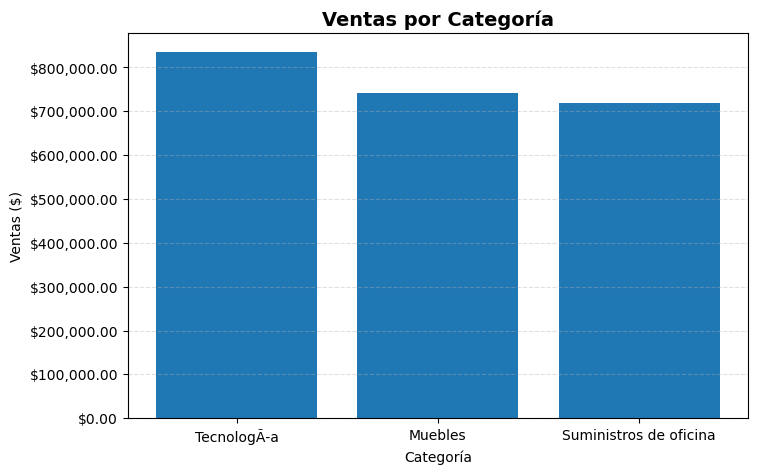

In [27]:
#Crea y ajusta el tamaño del grafico (8,5)
plt.figure(figsize=(8,5)) 
#Crea las barras de ejes(X: tegnologia, muebles, suministros de oficina) (Y: altura total de ventas en $ cada categoria)
plt.bar(
    ventas_categoria.index,
    ventas_categoria.values
)
#Titulo arriba del grafico
plt.title("Ventas por Categoría", fontsize=14, fontweight="bold")
#Nombre del eje X
plt.xlabel("Categoría")
#nombre al eje Y
plt.ylabel("Ventas ($)")
#lineas horinzontales punteadas de fondo
plt.grid(axis="y", linestyle="--", alpha=0.4)
#Formato a los numeros del eje Y con valor en dolares y comas
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.2f}')
)
#Muestra el garfico
plt.show()

### Gráfico 2: Ventas por Región

El siguiente gráfico muestra la distribución del volumen de ventas entre las diferentes regiones de productos.

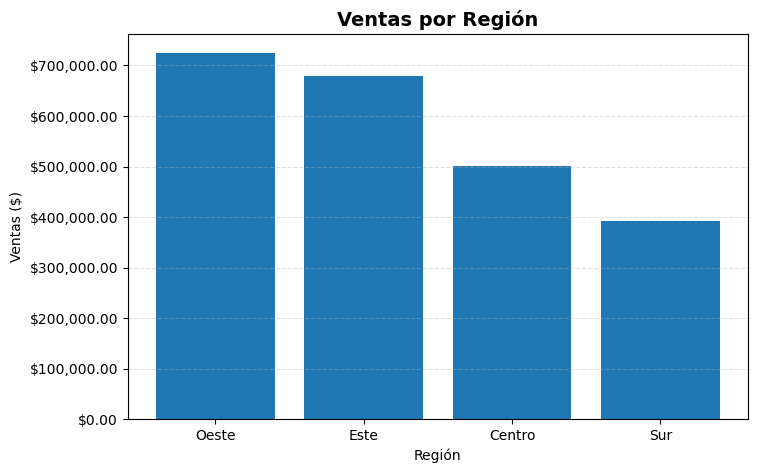

In [28]:

#Crea y ajusta el tamaño del grafico (8,5)
plt.figure(figsize=(8,5))
#Crea las barras de ejes(X: Region) (Y: Ventas)
plt.bar(
    ventas_region.index,
    ventas_region.values
)
#Titulo arriba del grafico
plt.title("Ventas por Región", fontsize=14, fontweight="bold")
plt.xlabel("Región")
plt.ylabel("Ventas ($)")
#lineas horinzontales punteadas de fondo
plt.grid(axis="y", linestyle="--", alpha=0.4)
#Formato a los numeros del eje Y con valor en dolares y comas
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.2f}')
)

plt.show()

### Gráfico 3: Ganancias por categoría

El siguiente gráfico muestra la distribución del volumen de ganancias entre las diferentes categorías de productos.

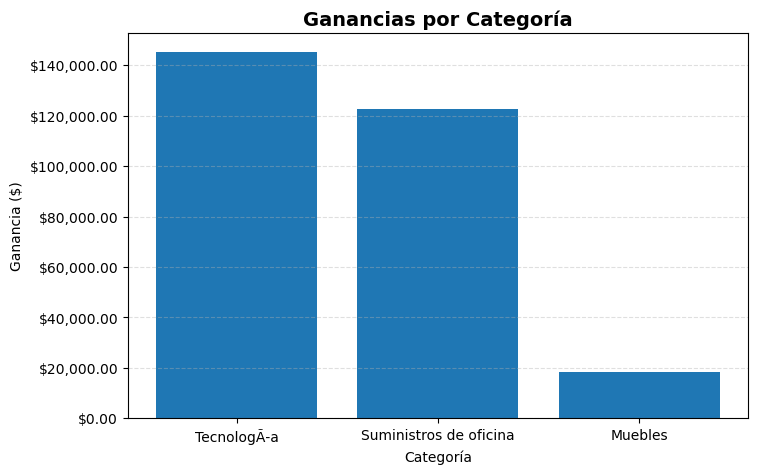

In [29]:
#Crea y ajusta el tamaño del grafico (8,5)
plt.figure(figsize=(8,5))
#Crea las barras de ejes(X: categorias) (Y: ganancias)
plt.bar(
    ganancia_categoria.index,
    ganancia_categoria.values
)
#Titulo arriba del grafico
plt.title("Ganancias por Categoría", fontsize=14, fontweight="bold")
#Nombre del eje X, Y en $
plt.xlabel("Categoría")
plt.ylabel("Ganancia ($)")
#lineas horinzontales punteadas de fondo
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Mostrar el eje Y en formato de dinero $ y comas
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.2f}')
)

plt.show()

### Gráfico 4: Histograma de Ventas

Este histograma muestra la distribución de las ventas registradas en el conjunto de datos. Permite identificar si la mayoría de las ventas corresponden a montos bajos, medios o altos, así como detectar posibles valores atípicos.

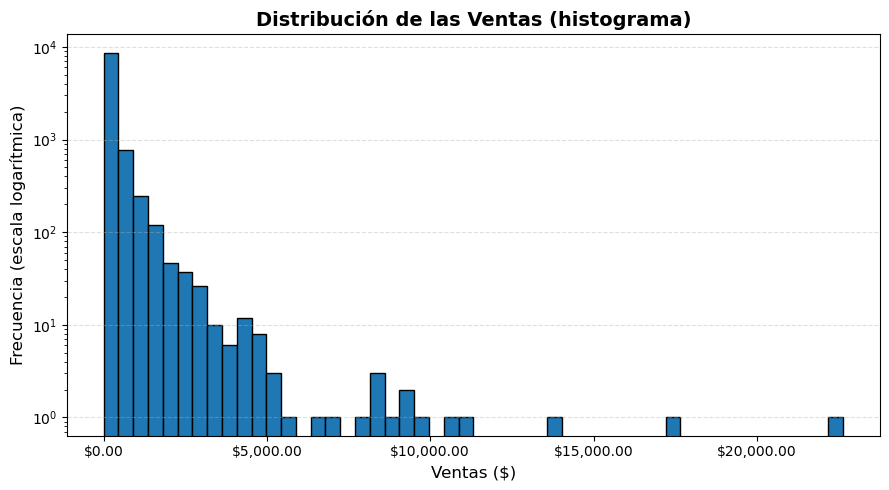

In [30]:
#Escala logaritmica tamaño del grafico
plt.figure(figsize=(9, 5))
#Realiza el histograma con los valores del dataframe
plt.hist(
    df["venta"],
    bins=50,       
    edgecolor="black",   
)
#REaliza la escala logaritmica por las ventas pequeñas
plt.yscale("log")
plt.title("Distribución de las Ventas (histograma)", fontsize=14, fontweight="bold")
plt.xlabel("Ventas ($)", fontsize=12)
plt.ylabel("Frecuencia (escala logarítmica)", fontsize=12)
#lineas horinzontales punteadas de fondo
plt.grid(axis="y", linestyle="--", alpha=0.4)
#Da forma de dinero al eje x
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.2f}')
)
#Ajusta automaticamente los margenes del titulo
plt.tight_layout()
plt.show() 

### Interpretación

El histograma permite visualizar cómo se distribuyen las ventas del conjunto de datos. La frecuencia de los valores facilita identificar el rango donde se concentra la mayor cantidad de transacciones y detectar posibles ventas de valores elevados o atípicos.

### Gráfico 5: Relación entre Descuento y Ganancia (Dispersión)

Este gráfico de dispersión permite analizar la relación entre el descuento aplicado y la ganancia obtenida en cada venta. Cada punto representa una transacción registrada en el conjunto de datos.

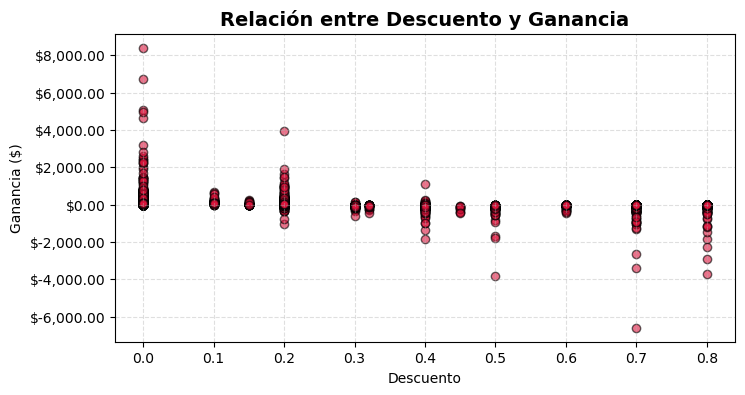

In [31]:

# Crear figura y tamaño
plt.figure(figsize=(8, 4))

# Gráfico de dispersión
plt.scatter(
    df["descuento"],
    df["ganancia"],
    c="crimson",
    alpha=0.6,
    edgecolors="black"
)

#Titulo arriba del grafico
plt.title("Relación entre Descuento y Ganancia", fontsize=14, fontweight="bold")
plt.xlabel("Descuento")
plt.ylabel("Ganancia ($)")

# Cuadrícula
plt.grid(True, linestyle="--", alpha=0.4)

# Formato del eje Y en dólares
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.2f}')
)

# Mostrar gráfico
plt.show()

### Interpretación

El gráfico de dispersión muestra la relación entre el descuento aplicado y la ganancia obtenida en cada venta. La distribución de los puntos permite observar si niveles más altos de descuento están asociados con una disminución de la rentabilidad o si existen valores atípicos que requieren un análisis adicional.

### Gráfico 6: Diagrama de Cajas de las Ganancias
El diagrama de dona o de anillo (Donut chart) permite analizar la distribución de las ganancias, identificar la mediana, la dispersión de los datos y detectar posibles valores atípicos.

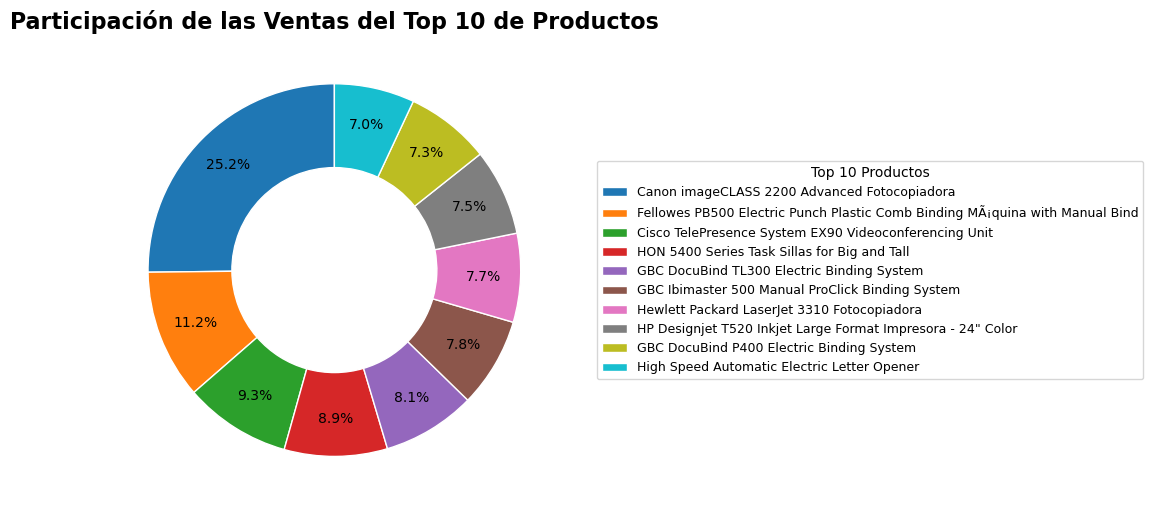

In [32]:
#Saca los productos que mas dinero generaron
top10 = (
    df.groupby("nombre_producto")["venta"]
      .sum() #suma total vendido $ cada producto
      .sort_values(ascending=False) #Ordena de mayor a menor
      .head(10) #solo los 10 primeros
)
# Crear figura y tamaño
fig, ax = plt.subplots(figsize=(10,8))
#Dibuja la dona
wedges, texts, autotexts = ax.pie(
    top10,
    autopct=lambda p: f'{p:.1f}%' if p >= 3 else '', #Escribe el % de cada pedazo
    startangle=90, #Dibuja desde arriba
    pctdistance=0.80, #Coloca el % a 80% del radio o centro de la dona
    wedgeprops=dict(width=0.45, edgecolor="white")#Convierte el pie en dona completo y separa los pedazos con lineas blancas
)
#Coloca la leyenda en costado derecho
ax.legend(
    wedges,
    top10.index,
    title="Top 10 Productos",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    fontsize=9
)
#Titulo grande y en negrita arriba
ax.set_title(
    "Participación de las Ventas del Top 10 de Productos",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Interpretación

#El diagrama de cajas muestra la distribución de las ganancias registradas en el conjunto de datos. Además de la mediana y la variabilidad de los datos, permite identificar la presencia de valores atípicos, los cuales representan ventas con ganancias significativamente diferentes al comportamiento general.